In [ ]:
import pandas as pd
df = pd.read_csv('ola.csv')

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Assuming 'count' is the target variable and 'datetime' is not a feature for the model yet.
# For simplicity, I'll drop 'datetime' and 'casual', 'registered' as features for now
# since 'count' is usually 'casual' + 'registered' and 'datetime' needs feature engineering.
features = ['season', 'weather', 'temp', 'humidity', 'windspeed']
X = df[features]
y = df['count']

# For cross-validation, we want to use the full dataset as the 'honest' set.
# So, we directly assign X and y.
X_honest = X
y_honest = y

# Initialize and train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_honest, y_honest) # Fit on the 'honest' data for cross-validation

# Initialize and train Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_honest, y_honest) # Fit on the 'honest' data for cross-validation

print("Models and data prepared for cross-validation.")

Models and data prepared for cross-validation.


##Understand the Data and Choose the Right Metrics
Since our dataset's target (count) is numerical and continuous, we are dealing with a Regression problem. We used MAE (Mean Absolute Error) because it tells us exactly how many rides our predictions are off by on average

## Use Cross-Validation for Real Generalization

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Re-initialize the models so the notebook remembers them
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Run 5-Fold Cross Validation using our honest data features
lr_cv_scores = cross_val_score(lr_model, X_honest, y_honest, cv=5, scoring='neg_mean_absolute_error')
rf_cv_scores = cross_val_score(rf_model, X_honest, y_honest, cv=5, scoring='neg_mean_absolute_error')

# 3. Convert to positive MAE scores
lr_cv_mae = -lr_cv_scores.mean()
rf_cv_mae = -rf_cv_scores.mean()

print(f"5-Fold Cross-Validation MAE for Linear Regression: {lr_cv_mae:.2f}")
print(f"5-Fold Cross-Validation MAE for Random Forest:     {rf_cv_mae:.2f}")

5-Fold Cross-Validation MAE for Linear Regression: 50.93
5-Fold Cross-Validation MAE for Random Forest:     52.34


## Visualize Results

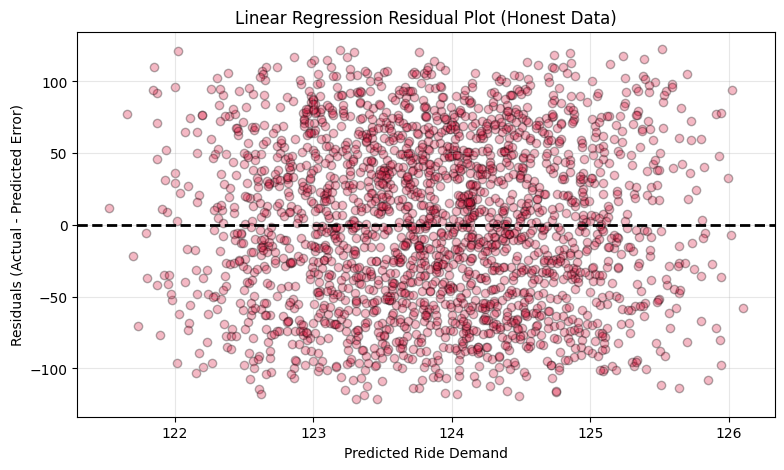

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split the 'honest' data into training and testing sets
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_honest, y_honest, test_size=0.2, random_state=42)

# 1. We need to make sure lr_model is fitted on the training split first
lr_model.fit(X_train_h, y_train_h)
honest_preds = lr_model.predict(X_test_h)

# 2. Calculate the prediction errors (Actual minus Predicted)
residuals = y_test_h - honest_preds

# 3. Plot the residuals
plt.figure(figsize=(9, 5))
plt.scatter(honest_preds, residuals, alpha=0.3, color='crimson', edgecolors='k')
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.title('Linear Regression Residual Plot (Honest Data)')
plt.xlabel('Predicted Ride Demand')
plt.ylabel('Residuals (Actual - Predicted Error)')
plt.grid(True, alpha=0.3)
plt.show()